# Assignment 1 — Epidemiological Models: Parameter Exploration

### Imports:

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import odeint

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


## Part 1: Parameter analysis function

### 1.1 Function implementation
We will use the SIRD model from practical to explore the effects of different recovery rates on the spread of an infectious disease. Some modifications will be done to the model to calculate the required statistics.

In [20]:
def sird_model(y, t, beta, gamma, mu):
    """
    SIRD model with death compartment

    Additional parameter:
    - mu: mortality rate

    New compartment:
    - D: Deaths
    """
    S, I, R, D = y
    N = S + I + R + D

    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I

    return dSdt, dIdt, dRdt, dDdt


test_result = sird_model([990, 10, 0, 0], 0, 0.3, 0.1, 0.01)
print(f"SIRD test result: {test_result}")
print("You should see 4 numbers!")

SIRD test result: (-2.97, 1.87, 1.0, 0.1)
You should see 4 numbers!


In [21]:
def analyze_recovery_rates(beta, mu, N = 1000, I0 = 10, simulation_days = 100):

    S0 = N - I0
    R0 = 0
    D0 = 0
    y0 = [S0, I0, R0, D0]

    t = np.linspace(0, simulation_days - 1, simulation_days)

    dataFrame = pd.DataFrame(columns=['gamma', 'R0', 'peak_infected', 'peak_day','total_deaths'])

    # create a loop for different gamma values, and run the same solver for analysis as in practical
    for gamma in [0.05, 0.1, 0.15, 0.2, 0.25]:
        sol = odeint(sird_model, y0, t, args=(beta, gamma, mu))
        S, I, R, D = sol.T
        dataFrame.loc[len(dataFrame)] = [gamma, beta/gamma, I.max(), np.argmax(I), D[-1]]
        plt.figure(figsize=(10, 6))
        plt.plot(t, S, 'b-', label='Susceptible', linewidth=2)
        plt.plot(t, I, 'r-', label='Infectious', linewidth=2)
        plt.plot(t, R, 'g-', label='Recovered', linewidth=2)
        plt.plot(t, D, 'k-', label='Deaths', linewidth=2)

        plt.xlabel('Time (days)')
        plt.ylabel('Population')
        plt.title(f'SIRD Model: β={beta}, γ={gamma}, μ={mu}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return dataFrame


### 1.3 Output

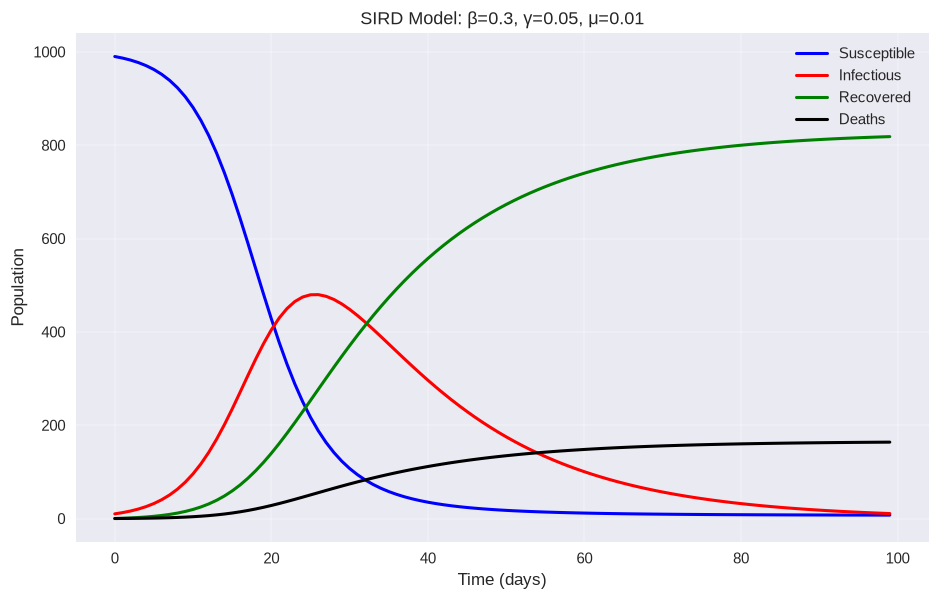

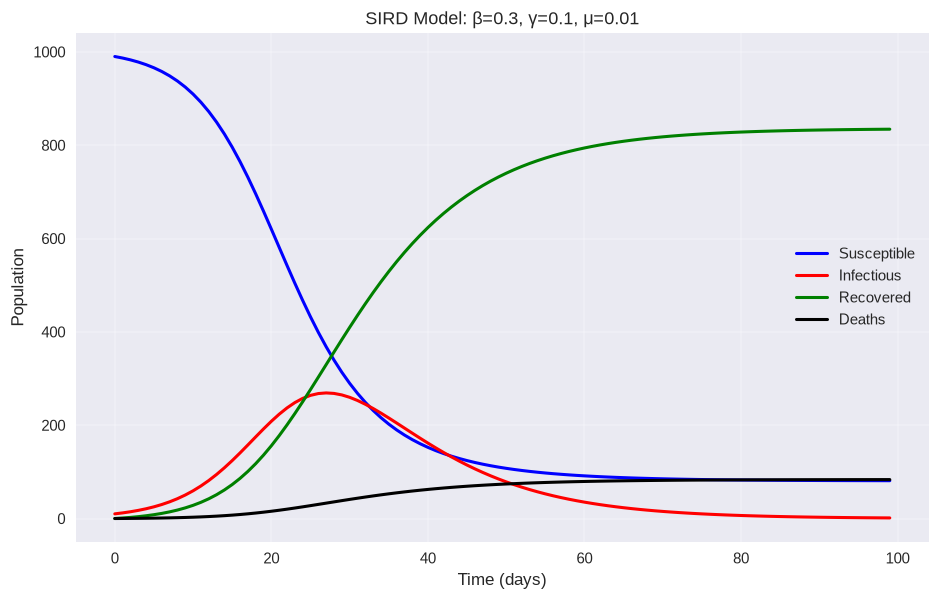

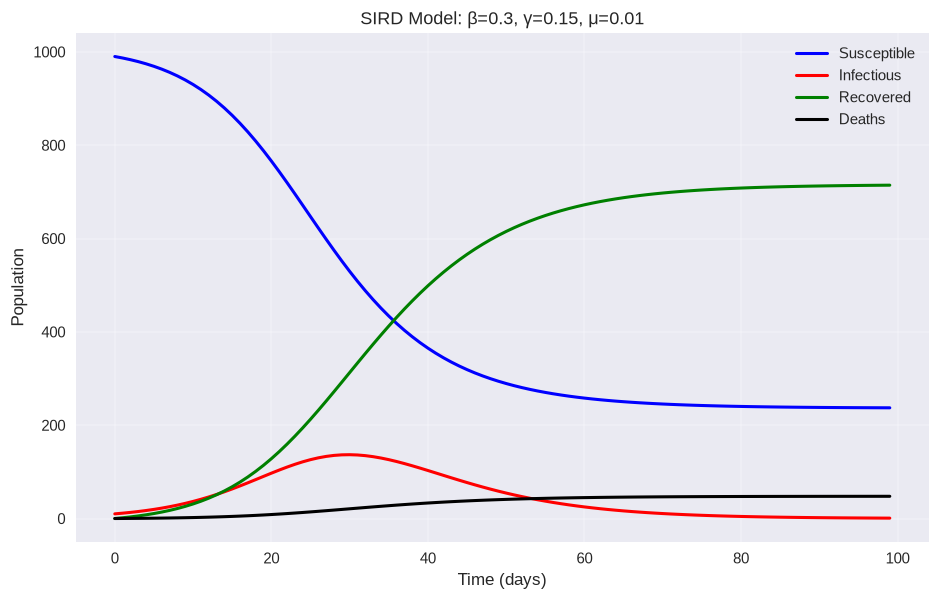

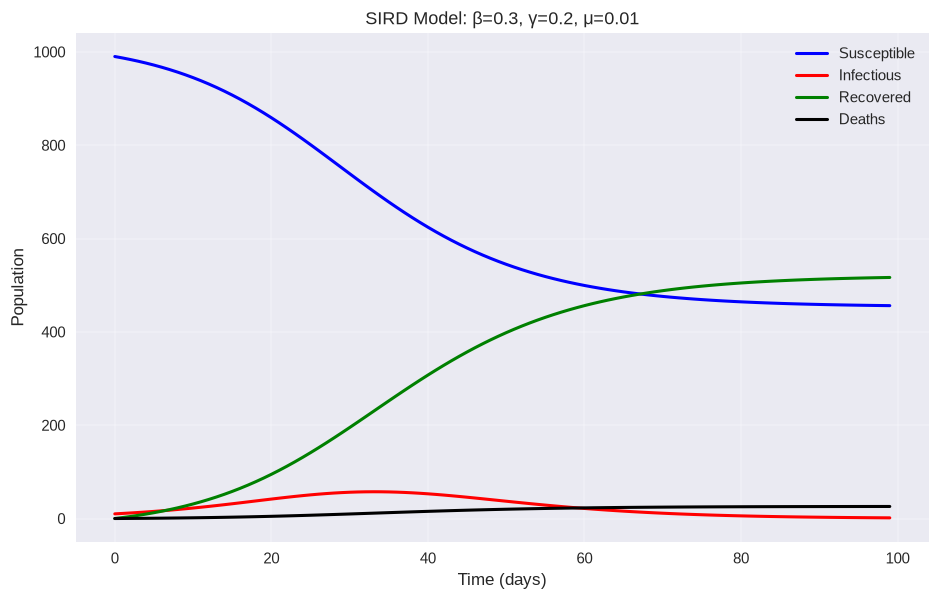

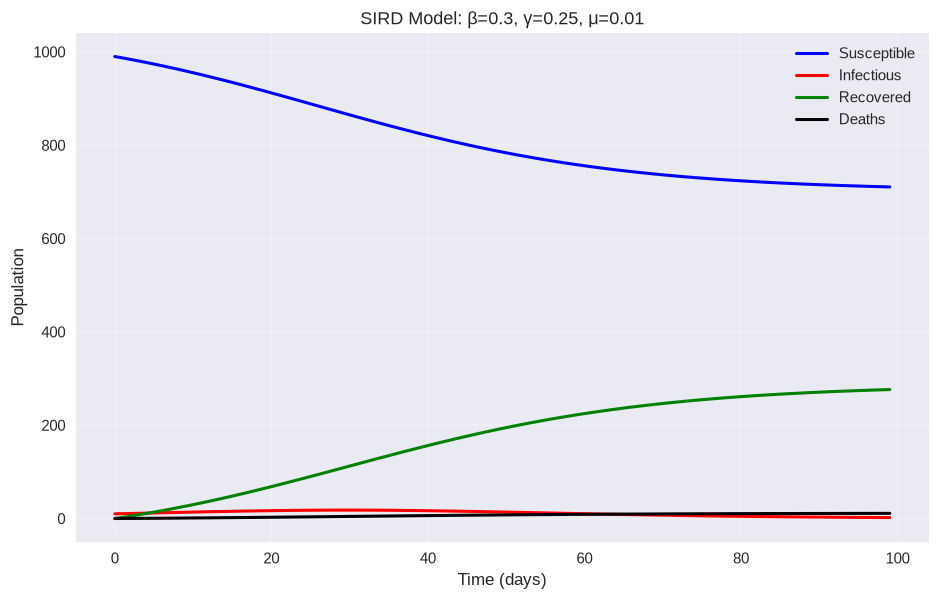

   gamma   R0  peak_infected  peak_day  total_deaths
0   0.05  6.0         479.74      26.0        163.67
1   0.10  3.0         269.14      27.0         83.43
2   0.15  2.0         136.76      30.0         47.62
3   0.20  1.5          57.36      33.0         25.83
4   0.25  1.2          18.02      30.0         11.06


In [22]:
# print the dataFrame
print(analyze_recovery_rates(0.3, 0.01))

## Part 2


## Part 3 — Policy Recommendations (20 points)

### 3.1 Parameter impact analysis

### 3.2 Intervention analysis

### 3.3 Real-world application

### 5. Conclusions
